## import libraries and data

In [19]:
from locale import normalize

%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from src.extraction import load_processed, FEATURE_COLUMNS
from src.classification import build_X_y, split_data, analyze_imbalance, train_model,evaluate_models, plot_all_confusion_matrices, plot_f1_comparison, cross_validate_models, plot_cv_boxplot
from sklearn.metrics import classification_report

df_clean_clusters = load_processed("df_clean_with_target.csv")
df_clean_clusters = df_clean_clusters[FEATURE_COLUMNS + ["target"]]

df_clean_clusters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,target
0,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084,Clients à Faible Activité
1,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,Clients à Risque
2,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742,Clients Premium
3,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,Clients à Faible Activité
4,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763,Clients à Faible Activité
...,...,...,...,...,...,...,...,...
8944,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462,Clients à Faible Activité
8945,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322,Clients à Faible Activité
8946,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775,Clients à Faible Activité
8947,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959,Clients à Faible Activité


## Build X / y and stratified train/test split

In [20]:
X, y = build_X_y(df_clean_clusters)

X_train, X_test, y_train, y_test = split_data(X, y)

# check if the Stratification have the same proportions
display(pd.DataFrame({
    "train" : y_train.value_counts(normalize=True),
    "test"  : y_test.value_counts(normalize=True)
}))

,train,test
target,,
Clients Premium,0.399078,0.398883
Clients à Faible Activité,0.333706,0.334078
Clients à Risque,0.267216,0.267039


## Class imbalance analysis

In [21]:
table, ratio, needs_resampling = analyze_imbalance(y_train)
display(table)
print(f"Imbalance ratio (largest / smallest): {ratio}")
print("Resampling needed:", needs_resampling)

SAMPLING = "over" if needs_resampling else "none"
print("Sampling strategy used in the pipeline:", SAMPLING)

,count,pct
target,,
Clients Premium,2857,39.9
Clients à Faible Activité,2389,33.4
Clients à Risque,1913,26.7


Imbalance ratio (largest / smallest): 1.49
Resampling needed: False
Sampling strategy used in the pipeline: none


## Training the 4 pipelines

In [22]:
pipelines, train_times = train_model(X_train, y_train, sampling=SAMPLING)

display(train_times)

for name, pipeline in pipelines.items():
    print(f"{name} test accuracy = {pipeline.score(X_test, y_test):.3f}")

pipelines["svm"]

,train_time_s
model,
random_forest,0.474
svm,2.146
decision_tree,0.034
logistic_regression,0.042


random_forest test accuracy = 0.974
svm test accuracy = 0.915
decision_tree test accuracy = 0.944
logistic_regression test accuracy = 0.902


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](3,)","['Clients Premium','Clients à Faible Activité','Clients à Risque']"
feature_names_in_,"ndarray[object](7,)","['BALANCE','PURCHASES','ONEOFF_PURCHASES',...,'CASH_ADVANCE', 'CREDIT_LIMIT','PAYMENTS']"
n_features_in_,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Evaluation on the test set,

In [23]:
comparison = evaluate_models(pipelines, X_test, y_test, train_times)
display(comparison)

for name, pipeline in pipelines.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pipeline.predict(X_test), digits=3))

,accuracy,precision_macro,recall_macro,f1_macro,train_time_s
model,,,,,
random_forest,0.9737,0.9749,0.9736,0.9742,0.474
decision_tree,0.9436,0.9429,0.9443,0.9436,0.034
svm,0.9151,0.9123,0.9206,0.9153,2.146
logistic_regression,0.9022,0.9021,0.9069,0.9040,0.042


===== random_forest =====
                           precision    recall  f1-score   support

          Clients Premium      0.973     0.973     0.973       714
Clients à Faible Activité      0.962     0.977     0.969       598
         Clients à Risque      0.989     0.971     0.980       478

                 accuracy                          0.974      1790
                macro avg      0.975     0.974     0.974      1790
             weighted avg      0.974     0.974     0.974      1790

===== svm =====
                           precision    recall  f1-score   support

          Clients Premium      0.949     0.881     0.914       714
Clients à Faible Activité      0.912     0.916     0.914       598
         Clients à Risque      0.876     0.964     0.918       478

                 accuracy                          0.915      1790
                macro avg      0.912     0.921     0.915      1790
             weighted avg      0.917     0.915     0.915      1790

===== decision

In [24]:
##

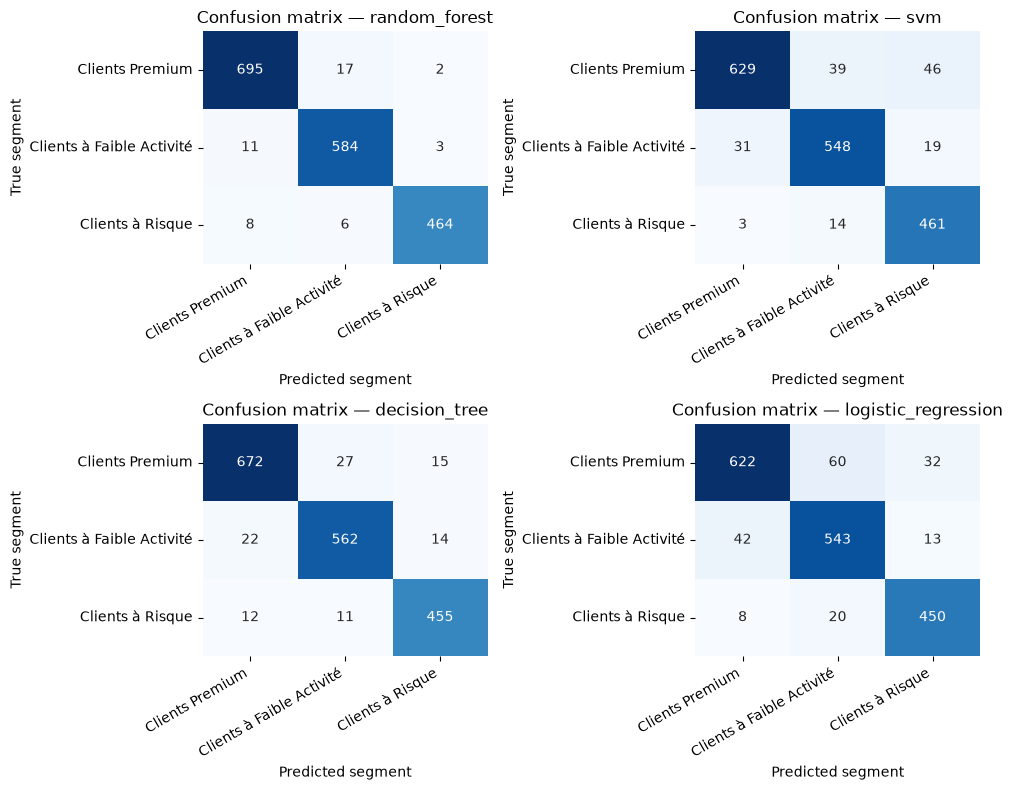

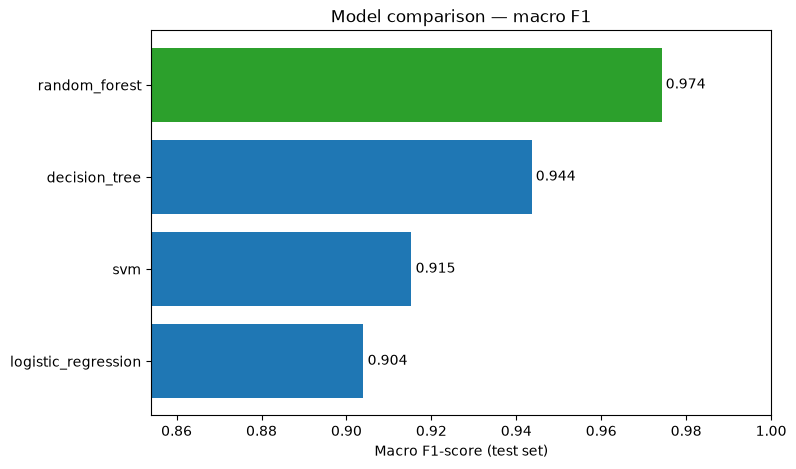

In [25]:
plot_all_confusion_matrices(pipelines, X_test, y_test)
plt.show()

plot_f1_comparison(comparison)
plt.show()

## Cross-validation (stability)

,mean,std,min,max
model,,,,
random_forest,0.9687,0.0049,0.9646,0.9772
decision_tree,0.9445,0.0067,0.9379,0.9525
svm,0.9095,0.0109,0.8958,0.9255
logistic_regression,0.9055,0.0084,0.8978,0.9186


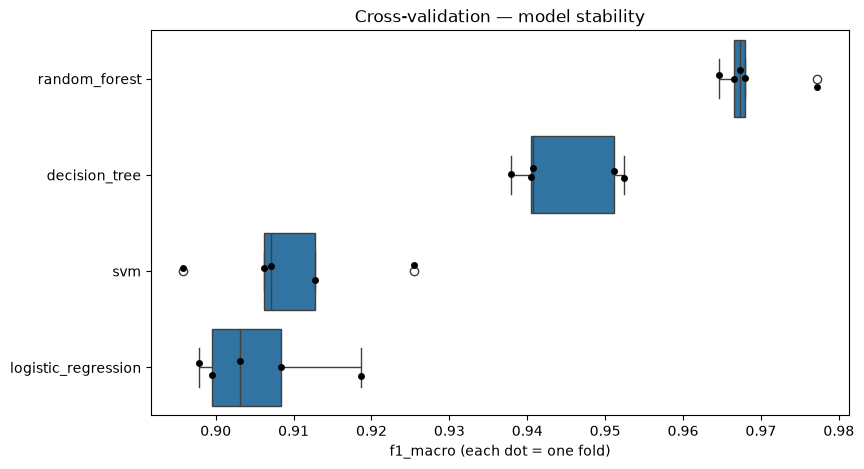

In [26]:
cv_scores = cross_validate_models(X_train, y_train, sampling=SAMPLING)

summary = (cv_scores.groupby("model")["f1_macro"]
           .agg(["mean", "std", "min", "max"])
           .sort_values("mean", ascending=False).round(4))
display(summary)

plot_cv_boxplot(cv_scores)
plt.show()